# DreamBrush 3DGS Training

This notebook turns a DreamBrush `CaptureBundle` into a Nerfstudio-ready dataset, trains a 3D Gaussian Splat (Splatfacto), and exports a PLY for the iOS viewer.

**Pipeline**
1. Download bundle from Google Drive
2. Convert to `transforms.json` + `images/`
3. Build `sparse_pc.ply` from LiDAR depth for better Splatfacto initialization
4. Train (`ns-train splatfacto`)
5. Export PLY (`ns-export gaussian-splat`)

> Note: The app exports camera transforms in **row-major** layout (as required by Nerfstudio), so this notebook does not transpose matrices.

## 0) Environment setup (GPU VM)

This workflow expects a CUDA-capable GPU for training. Run this cell once per VM:

In [ ]:
import os, sys, subprocess, venv, textwrap, importlib

# --- config ---
VENV_DIR = ".venv"
REQS = ["nerfstudio==1.1.5", "gdown", "imageio", "pillow", "tqdm", "matplotlib", "open3d", "pyyaml"]
# --------------

def run(cmd, **kwargs):
    print(">>", " ".join(cmd))
    subprocess.run(cmd, check=True, **kwargs)

# 1) Create venv that can SEE the preinstalled system packages (incl. torch/cuda)
if not os.path.isdir(VENV_DIR):
    print(f"Creating venv at {VENV_DIR} (with system-site-packages)...")
    venv.EnvBuilder(with_pip=True, system_site_packages=True).create(VENV_DIR)
else:
    print(f"Venv already exists at {VENV_DIR}")

vpy = os.path.join(VENV_DIR, "bin", "python")
if not os.path.exists(vpy):
    raise RuntimeError(f"Expected venv python at {vpy}, but it wasn't found.")

# 2) Tooling
run([vpy, "-m", "pip", "install", "-U", "pip", "setuptools", "wheel"])

# 3) Fix the common Ubuntu/apt "distutils blinker 1.4 can't uninstall" issue:
#    shadow it inside the venv instead of trying to remove the system one.
run([vpy, "-m", "pip", "install", "--ignore-installed", "blinker>=1.6"])

# 4) Pin the *system* torch stack so pip won't download/replace it
constraints_path = "/tmp/torch-constraints.txt"
pin_code = r"""
import importlib.metadata as md
pins=[]
for name in ("torch","torchvision","torchaudio"):
    try:
        pins.append(f"{name}=={md.version(name)}")
    except md.PackageNotFoundError:
        pass
path = """ + repr(constraints_path) + r"""
with open(path,"w") as f:
    f.write("\n".join(pins) + ("\n" if pins else ""))
print(path)
print(open(path).read() if pins else "(no torch packages found to pin)")
"""
out = subprocess.check_output([vpy, "-c", pin_code], text=True)
print("Torch constraints:\n" + out)

# 5) Install your deps, respecting the torch constraints (so no slow torch install)
run([vpy, "-m", "pip", "install", "-c", constraints_path, *REQS])

# 6) Make this venv usable as a Jupyter kernel (optional but recommended)
run([vpy, "-m", "pip", "install", "-c", constraints_path, "ipykernel"])
run([vpy, "-m", "ipykernel", "install", "--user", "--name", "runpod-nerf", "--display-name", "Python (runpod-nerf)"])

# 7) Also make venv packages importable *in the current kernel* (no restart needed)
#    (This is a pragmatic hack: we add the venv site-packages to sys.path.)
site_pkgs = subprocess.check_output([vpy, "-c", "import site; print(site.getsitepackages()[0])"], text=True).strip()
if site_pkgs not in sys.path:
    sys.path.insert(0, site_pkgs)
importlib.invalidate_caches()

os.environ["VIRTUAL_ENV"] = os.path.abspath(VENV_DIR)
os.environ["PATH"] = os.path.abspath(os.path.join(VENV_DIR, "bin")) + os.pathsep + os.environ.get("PATH", "")

print("\n✅ Done.")
print("Best practice: switch your notebook kernel to 'Python (runpod-nerf)' for a clean env.")
print("But you can also keep going in this kernel now; venv site-packages were added to sys.path.")

## 1) Imports + configuration

Fill in your Google Drive link and choose output paths.

In [2]:
from __future__ import annotations

import json
import math
import os
import re
import shutil
import zipfile
from pathlib import Path

import numpy as np
import imageio.v2 as imageio
from PIL import Image
from tqdm import tqdm

# ==================== USER CONFIG ====================
GDRIVE_URL = "https://drive.google.com/file/d/1jXq_tN9LEi6ZTdkt6zT0zG5HK8uN1QWA/view?usp=sharing"

WORK_DIR = Path.cwd() / "3dgs_train"
DOWNLOAD_DIR = WORK_DIR / "downloads"
EXTRACT_DIR = WORK_DIR / "bundles"
DATASET_DIR = WORK_DIR / "nerfstudio_dataset"
EXPORT_DIR = WORK_DIR / "exports"

# ==================== FRAME SELECTION ====================
# USE_KEYFRAMES=False uses ALL captured frames (recommended for quality)
# USE_KEYFRAMES=True uses only ARKit-selected keyframes (faster, less data)
USE_KEYFRAMES = False      # Changed: use all frames for better coverage
FRAME_STRIDE = 1           # Keep every Nth frame (1 = all, 2 = half, etc.)
MAX_FRAMES = None          # Cap number of frames (None = no limit)

# ==================== POINT CLOUD CONFIG ====================
DEPTH_STRIDE = 2           # Downsample depth pixels (lower = more points, better init)
MIN_DEPTH_M = 0.2          # Minimum depth in meters
MAX_DEPTH_M = 5.0          # Maximum depth (reduced for indoor scenes)
VOXEL_SIZE_M = 0.01        # Voxel size for downsampling (1cm = finer detail)
MAX_POINTS_PER_FRAME = 300_000  # Max points per frame before random sampling

# ==================== COORDINATE CONVERSION ====================
# If you see mirrored results, try enabling this camera-axis conversion.
APPLY_CAMERA_AXIS_CONVERSION = False
CAMERA_AXIS_CONVERSION = np.diag([1.0, 1.0, -1.0, 1.0]).astype(np.float32)

# ==================== TRAINING HYPERPARAMETERS ====================
# These are passed to ns-train splatfacto
TRAINING_CONFIG = {
    # Iteration control
    "max_num_iterations": 30000,      # Default is 30000, increase for better quality
    
    # Culling thresholds - CRITICAL for quality
    # Lower cull_alpha_thresh = keep more semi-transparent gaussians = better quality
    "cull_alpha_thresh": 0.005,       # Default 0.1, lower keeps more splats
    "continue_cull_post_densification": False,  # Don't cull after 15k steps
    
    # Densification - controls how aggressively new gaussians are created
    "densify_grad_thresh": 0.0004,    # Default 0.0008, lower = more aggressive densification
    
    # Resolution schedule - training resolution ramp-up
    "num_downscales": 2,              # Start at 1/4 resolution, ramp up
    "resolution_schedule": 3000,      # Double resolution every N steps
    
    # Refinement schedule
    "refine_every": 100,              # Densify/cull every N steps
    "stop_split_at": 15000,           # Stop splitting gaussians at this step
    
    # Quality vs size tradeoff
    # Note: More gaussians = better quality but larger file & slower mobile rendering
    # iPhone 13 Pro can handle ~1-2M splats at 15fps in Quality mode
    "use_scale_regularization": True, # Reduces spikey artifacts
    "max_gauss_ratio": 5.0,           # Default 10.0, lower = more uniform splats
    
    # Loss weights
    "ssim_lambda": 0.2,               # SSIM loss weight (structural similarity)
}

# ==================== iOS RENDER TARGETS ====================
# Reference for splat count targets:
# - iPhone 13 Pro Quality mode: renders all splats at 15fps
# - iPhone 13 Pro Balanced mode: caps at ~60,000 splats
# - iPhone 13 Pro Fast mode: caps at ~20,000 splats
# Aim for 500K-1.5M total splats for good quality with reasonable mobile performance

DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
DATASET_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration loaded.")
print(f"  USE_KEYFRAMES: {USE_KEYFRAMES}")
print(f"  FRAME_STRIDE: {FRAME_STRIDE}")
print(f"  MAX_FRAMES: {MAX_FRAMES}")
print(f"  VOXEL_SIZE_M: {VOXEL_SIZE_M}m")
print(f"  Training iterations: {TRAINING_CONFIG['max_num_iterations']}")
print(f"  Cull alpha thresh: {TRAINING_CONFIG['cull_alpha_thresh']}")

Configuration loaded.
  USE_KEYFRAMES: False
  FRAME_STRIDE: 1
  MAX_FRAMES: None
  VOXEL_SIZE_M: 0.01m
  Training iterations: 30000
  Cull alpha thresh: 0.005


## 2) Download + extract bundle from Google Drive

In [3]:
import importlib


def extract_gdrive_file_id(url: str) -> str | None:
    if not url:
        return None
    # Patterns: .../file/d/<ID>/view or id=<ID>
    match = re.search(r"/d/([a-zA-Z0-9_-]+)", url)
    if match:
        return match.group(1)
    match = re.search(r"id=([a-zA-Z0-9_-]+)", url)
    if match:
        return match.group(1)
    return None


def download_from_gdrive(url: str, out_path: Path) -> Path:
    if out_path.exists():
        return out_path
    file_id = extract_gdrive_file_id(url)
    if not file_id:
        raise ValueError("Could not extract file id from GDRIVE_URL. Use a share link or '?id=' URL.")

    gdown = importlib.import_module("gdown")
    download_url = f"https://drive.google.com/uc?id={file_id}"
    gdown.download(download_url, str(out_path), quiet=False)
    if not out_path.exists():
        raise RuntimeError("Download failed; file not found after gdown.")
    return out_path


zip_path = DOWNLOAD_DIR / "capture_bundle.zip"
if GDRIVE_URL:
    zip_path = download_from_gdrive(GDRIVE_URL, zip_path)
else:
    raise ValueError("Set GDRIVE_URL before running this cell.")

# Extract
bundle_root = EXTRACT_DIR / zip_path.stem
if not bundle_root.exists():
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(bundle_root)

# Find CaptureBundle_* folder
bundle_dirs = [p for p in bundle_root.rglob("CaptureBundle_*") if p.is_dir()]

non_macos = [p for p in bundle_dirs if "__MACOSX" not in p.parts]
if not bundle_dirs:
    raise FileNotFoundError("No CaptureBundle_* folder found in extracted archive")

bundle_dir = non_macos[0] if non_macos else bundle_dirs[0]
print("Found bundle:", bundle_dir)

Downloading...
From (original): https://drive.google.com/uc?id=1jXq_tN9LEi6ZTdkt6zT0zG5HK8uN1QWA
From (redirected): https://drive.google.com/uc?id=1jXq_tN9LEi6ZTdkt6zT0zG5HK8uN1QWA&confirm=t&uuid=5772be44-6ad6-42a4-b061-1b1e95738773
To: /workspace/3dgs_train/downloads/capture_bundle.zip
100%|██████████| 632M/632M [00:03<00:00, 164MB/s]  


Found bundle: /workspace/3dgs_train/bundles/capture_bundle/training_data/CaptureBundle_C5CB738A-DDEC-46AA-BD3E-7ABCD6FF8A32


## 3) Inspect bundle + load anchors

In [4]:
manifest = json.loads((bundle_dir / "manifest.json").read_text())
anchors = json.loads((bundle_dir / "anchors.json").read_text())

print("Bundle ID:", manifest.get("bundleId"))
print("Frame count:", manifest.get("captureStats", {}).get("frameCount"))
print("Keyframe count:", manifest.get("captureStats", {}).get("keyframeCount"))
print("Depth enabled:", manifest.get("captureSettings", {}).get("depthEnabled"))
print("Coordinate conventions:", manifest.get("coordinateConventions", {}))
print("Capture duration:", f"{manifest.get('captureStats', {}).get('durationSeconds', 0):.1f}s")

# Warn if using keyframes when we have many more frames
frame_count = manifest.get("captureStats", {}).get("frameCount", 0)
keyframe_count = manifest.get("captureStats", {}).get("keyframeCount", 0)
if USE_KEYFRAMES and frame_count > keyframe_count * 2:
    print(f"\n⚠️  WARNING: Using only {keyframe_count} keyframes out of {frame_count} total frames.")
    print("    Consider setting USE_KEYFRAMES=False for better quality.")

layout = manifest.get("coordinateConventions", {}).get("matrixLayout")
if layout and layout != "row_major":
    raise ValueError(f"This bundle uses matrixLayout={layout}. Re-export with row_major to avoid transpose in training.")

root_anchor = anchors.get("rootAnchor", {})
root_transform = root_anchor.get("transform")
if not root_transform:
    raise ValueError("anchors.json missing rootAnchor.transform")

# Row-major 4x4
T_root_world = np.array(root_transform, dtype=np.float32)
print("\nRoot anchor transform (row-major):\n", T_root_world)

Bundle ID: C5CB738A-DDEC-46AA-BD3E-7ABCD6FF8A32
Frame count: 811
Keyframe count: 156
Depth enabled: True
Coordinate conventions: {'handedness': 'right', 'intrinsicsLayout': 'row_major', 'matrixLayout': 'row_major', 'transformDirection': 'camera_to_world', 'units': 'meters', 'upAxis': 'Y'}
Capture duration: 81.1s

Root anchor transform (row-major):
 [[ 0.04674459  0.9981149   0.0397684  -0.03171891]
 [-0.81257087  0.01483928  0.58267325 -0.08032604]
 [ 0.5809848  -0.05955147  0.8117328   0.06167838]
 [ 0.          0.          0.          1.        ]]


## 4) Select frames

By default, uses ALL captured frames (not just keyframes) for better quality.

In [5]:
keyframes_dir = bundle_dir / "keyframes"
frames_meta_dir = bundle_dir / "frames" / "meta"
frames_rgb_dir = bundle_dir / "frames" / "rgb"
frames_depth_dir = bundle_dir / "frames" / "depth"

if USE_KEYFRAMES:
    frame_ids = sorted([int(p.stem) for p in keyframes_dir.glob("*.jpg")])
    print(f"Using KEYFRAMES only")
else:
    frame_ids = sorted([int(p.stem) for p in frames_rgb_dir.glob("*.jpg")])
    print(f"Using ALL frames")

# Apply stride and max
frame_ids = frame_ids[::FRAME_STRIDE]
if MAX_FRAMES:
    frame_ids = frame_ids[:MAX_FRAMES]

print(f"Selected {len(frame_ids)} frames (stride={FRAME_STRIDE}, max={MAX_FRAMES})")

Using ALL frames
Selected 811 frames (stride=1, max=None)


## 5) Build Nerfstudio dataset (images + transforms.json)

In [6]:
from datetime import datetime


def load_frame_meta(frame_id: int) -> dict:
    meta_path = frames_meta_dir / f"{frame_id:06d}.json"
    if not meta_path.exists():
        raise FileNotFoundError(f"Missing meta for frame {frame_id}: {meta_path}")
    return json.loads(meta_path.read_text())


def rows_to_matrix(rows: list[list[float]]) -> np.ndarray:
    return np.array(rows, dtype=np.float32)


def intrinsics_from_meta(meta: dict):
    intr = meta["camera"]["intrinsics"]
    fx = intr[0][0]
    fy = intr[1][1]
    cx = intr[0][2]
    cy = intr[1][2]
    w = meta["camera"]["imageResolution"]["width"]
    h = meta["camera"]["imageResolution"]["height"]
    return fx, fy, cx, cy, w, h


# Dataset target
dataset_name = bundle_dir.name
dataset_dir = DATASET_DIR / dataset_name
images_dir = dataset_dir / "images"
images_dir.mkdir(parents=True, exist_ok=True)

frames = []
intrinsics_list = []

for frame_id in tqdm(frame_ids, desc="Processing frames"):
    meta = load_frame_meta(frame_id)
    fx, fy, cx, cy, w, h = intrinsics_from_meta(meta)
    intrinsics_list.append([fx, fy, cx, cy, w, h])

    # Copy image - always from frames/rgb for consistency (even for keyframe IDs)
    src_img = frames_rgb_dir / f"{frame_id:06d}.jpg"
    if not src_img.exists() and USE_KEYFRAMES:
        # Fallback to keyframes dir if frame not in rgb
        src_img = keyframes_dir / f"{frame_id:06d}.jpg"
    dst_img = images_dir / f"{frame_id:06d}.jpg"
    if not dst_img.exists():
        shutil.copy2(src_img, dst_img)

    # Camera transform: row-major
    T_cam_world = rows_to_matrix(meta["camera"]["transform"])
    T_cam_anchor = np.linalg.inv(T_root_world) @ T_cam_world
    if APPLY_CAMERA_AXIS_CONVERSION:
        T_cam_anchor = T_cam_anchor @ CAMERA_AXIS_CONVERSION

    frames.append({
        "file_path": f"images/{frame_id:06d}.jpg",
        "transform_matrix": T_cam_anchor.tolist()
    })

# Check intrinsics consistency
intrinsics_arr = np.array(intrinsics_list)
max_spread = intrinsics_arr.max(axis=0) - intrinsics_arr.min(axis=0)
print("Intrinsics max spread [fx, fy, cx, cy, w, h]:", max_spread)

fx, fy, cx, cy, w, h = intrinsics_list[0]

transforms = {
    "camera_model": "OPENCV",
    "fl_x": float(fx),
    "fl_y": float(fy),
    "cx": float(cx),
    "cy": float(cy),
    "w": int(w),
    "h": int(h),
    "ply_file_path": "sparse_pc.ply",
    "frames": frames
}

(dataset_dir / "transforms.json").write_text(json.dumps(transforms, indent=2))
print(f"Wrote transforms.json to {dataset_dir}")
print(f"  - {len(frames)} frames")
print(f"  - Image resolution: {w}x{h}")
print(f"  - Focal length: fx={fx:.1f}, fy={fy:.1f}")

Processing frames: 100%|██████████| 811/811 [00:13<00:00, 58.14it/s]

Intrinsics max spread [fx, fy, cx, cy, w, h]: [20.5565 20.5565  3.5511  1.6975  0.      0.    ]
Wrote transforms.json to /workspace/3dgs_train/nerfstudio_dataset/CaptureBundle_C5CB738A-DDEC-46AA-BD3E-7ABCD6FF8A32
  - 811 frames
  - Image resolution: 1920x1440
  - Focal length: fx=1344.5, fy=1344.5


## 6) Build `sparse_pc.ply` from depth

This gives Splatfacto a strong geometric initialization. Better init = better results.

In [7]:
def load_depth_m(path: Path) -> np.ndarray:
    depth = imageio.imread(path)
    if depth.dtype != np.uint16:
        depth = depth.astype(np.uint16)
    return depth.astype(np.float32) / 1000.0  # mm -> meters


def unproject_depth(depth_m: np.ndarray, fx: float, fy: float, cx: float, cy: float, stride: int):
    h, w = depth_m.shape
    us = np.arange(0, w, stride)
    vs = np.arange(0, h, stride)
    uu, vv = np.meshgrid(us, vs)
    z = depth_m[np.ix_(vs, us)]
    mask = (z > MIN_DEPTH_M) & (z < MAX_DEPTH_M)

    u = uu[mask]
    v = vv[mask]
    z = z[mask]

    x = (u - cx) / fx * z
    y = (v - cy) / fy * z
    pts = np.stack([x, y, z], axis=1).astype(np.float32)
    return pts, (u, v)


def voxel_downsample(points: np.ndarray, colors: np.ndarray | None, voxel_size: float):
    if voxel_size <= 0:
        return points, colors
    voxel = np.floor(points / voxel_size).astype(np.int32)
    _, unique_idx = np.unique(voxel, axis=0, return_index=True)
    if colors is None:
        return points[unique_idx], None
    return points[unique_idx], colors[unique_idx]


def write_ply_ascii(path: Path, points: np.ndarray, colors: np.ndarray | None = None):
    with path.open("w", encoding="ascii") as f:
        f.write("ply\nformat ascii 1.0\n")
        f.write(f"element vertex {len(points)}\n")
        f.write("property float x\nproperty float y\nproperty float z\n")
        if colors is not None:
            f.write("property uchar red\nproperty uchar green\nproperty uchar blue\n")
        f.write("end_header\n")
        if colors is None:
            for x, y, z in points:
                f.write(f"{x} {y} {z}\n")
        else:
            for (x, y, z), (r, g, b) in zip(points, colors):
                f.write(f"{x} {y} {z} {int(r)} {int(g)} {int(b)}\n")


all_points = []
all_colors = []

# Use ALL frames for depth (not just selected training frames) for better init
depth_frame_ids = sorted([int(p.stem) for p in frames_depth_dir.glob("*.png")])
print(f"Building sparse point cloud from {len(depth_frame_ids)} depth frames...")

for frame_id in tqdm(depth_frame_ids, desc="Depth to points"):
    meta = load_frame_meta(frame_id)
    depth_meta = meta.get("depth") or {}
    if not depth_meta.get("available"):
        continue

    depth_path = frames_depth_dir / f"{frame_id:06d}.png"
    if not depth_path.exists():
        continue

    depth_m = load_depth_m(depth_path)
    # Scale intrinsics to depth resolution
    fx, fy, cx, cy, w, h = intrinsics_from_meta(meta)
    depth_h, depth_w = depth_m.shape
    fx_d = fx * (depth_w / w)
    fy_d = fy * (depth_h / h)
    cx_d = cx * (depth_w / w)
    cy_d = cy * (depth_h / h)

    pts_cam, (u_depth, v_depth) = unproject_depth(depth_m, fx_d, fy_d, cx_d, cy_d, DEPTH_STRIDE)
    if pts_cam.shape[0] == 0:
        continue

    # Transform to anchor space
    T_cam_world = rows_to_matrix(meta["camera"]["transform"])
    T_cam_anchor = np.linalg.inv(T_root_world) @ T_cam_world
    if APPLY_CAMERA_AXIS_CONVERSION:
        T_cam_anchor = T_cam_anchor @ CAMERA_AXIS_CONVERSION

    ones = np.ones((pts_cam.shape[0], 1), dtype=np.float32)
    pts_h = np.concatenate([pts_cam, ones], axis=1)
    pts_anchor = (T_cam_anchor @ pts_h.T).T[:, :3]

    # Sample colors from RGB
    img_path = frames_rgb_dir / f"{frame_id:06d}.jpg"
    if not img_path.exists():
        img_path = keyframes_dir / f"{frame_id:06d}.jpg"
    if img_path.exists():
        rgb = np.array(Image.open(img_path).convert("RGB"))
        rgb_h, rgb_w, _ = rgb.shape
        u_rgb = np.clip((u_depth * (rgb_w / depth_w)).astype(np.int32), 0, rgb_w - 1)
        v_rgb = np.clip((v_depth * (rgb_h / depth_h)).astype(np.int32), 0, rgb_h - 1)
        colors = rgb[v_rgb, u_rgb]
    else:
        colors = np.full((pts_anchor.shape[0], 3), 128, dtype=np.uint8)

    if MAX_POINTS_PER_FRAME and pts_anchor.shape[0] > MAX_POINTS_PER_FRAME:
        idx = np.random.choice(pts_anchor.shape[0], MAX_POINTS_PER_FRAME, replace=False)
        pts_anchor = pts_anchor[idx]
        colors = colors[idx]

    all_points.append(pts_anchor)
    all_colors.append(colors)

if not all_points:
    raise RuntimeError("No depth points generated. Check depth availability and paths.")

points = np.concatenate(all_points, axis=0)
colors = np.concatenate(all_colors, axis=0)
print(f"Raw points: {points.shape[0]:,}")

points, colors = voxel_downsample(points, colors, VOXEL_SIZE_M)
print(f"After voxel downsampling ({VOXEL_SIZE_M*100:.0f}cm): {points.shape[0]:,}")

sparse_path = dataset_dir / "sparse_pc.ply"
write_ply_ascii(sparse_path, points, colors)
print(f"Wrote sparse point cloud: {sparse_path}")

Building sparse point cloud from 811 depth frames...


Depth to points: 100%|██████████| 811/811 [00:30<00:00, 26.64it/s]


Raw points: 734,400
After voxel downsampling (1cm): 707,193
Wrote sparse point cloud: /workspace/3dgs_train/nerfstudio_dataset/CaptureBundle_C5CB738A-DDEC-46AA-BD3E-7ABCD6FF8A32/sparse_pc.ply


## 7) Sanity checks

Point cloud bounds (m):
  min: [-6.66, -6.08, -2.26]
  max: [6.03, 6.36, 6.74]
  extents: [12.69, 12.44, 9.00]m


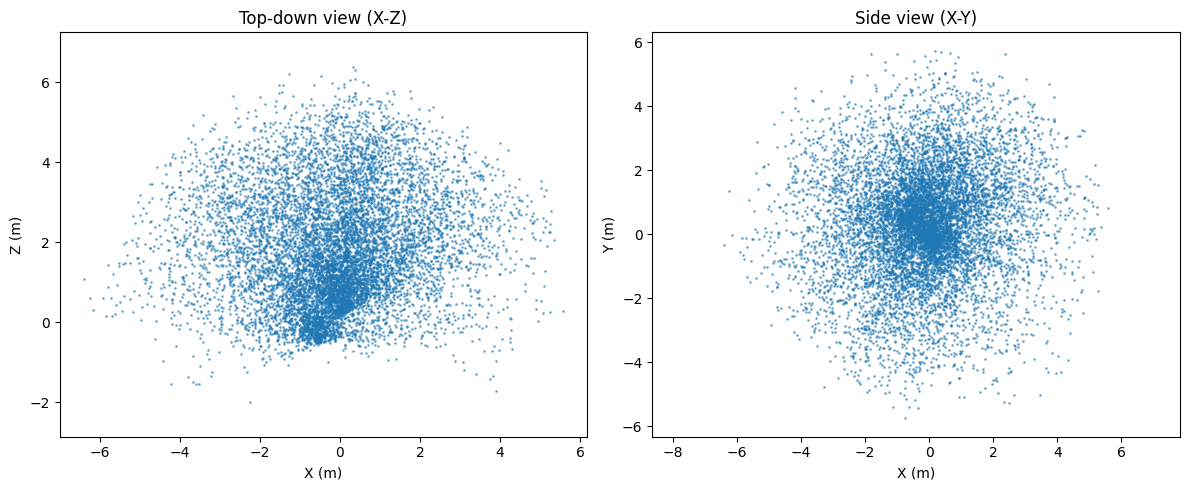

In [8]:
# Basic bbox sanity check
mins = points.min(axis=0)
maxs = points.max(axis=0)
extents = maxs - mins
print("Point cloud bounds (m):")
print(f"  min: [{mins[0]:.2f}, {mins[1]:.2f}, {mins[2]:.2f}]")
print(f"  max: [{maxs[0]:.2f}, {maxs[1]:.2f}, {maxs[2]:.2f}]")
print(f"  extents: [{extents[0]:.2f}, {extents[1]:.2f}, {extents[2]:.2f}]m")

# Warn if scene is very large
if extents.max() > 20:
    print("\n⚠️  WARNING: Scene extents are large. Check for outlier depth values.")

# Quick 2D scatter preview (top-down XZ)
import matplotlib.pyplot as plt

sample_count = min(10000, points.shape[0])
sample = points[np.random.choice(points.shape[0], sample_count, replace=False)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Top-down view (X-Z)
axes[0].scatter(sample[:, 0], sample[:, 2], s=1, alpha=0.5)
axes[0].set_title("Top-down view (X-Z)")
axes[0].set_xlabel("X (m)")
axes[0].set_ylabel("Z (m)")
axes[0].axis("equal")

# Side view (X-Y)
axes[1].scatter(sample[:, 0], sample[:, 1], s=1, alpha=0.5)
axes[1].set_title("Side view (X-Y)")
axes[1].set_xlabel("X (m)")
axes[1].set_ylabel("Y (m)")
axes[1].axis("equal")

plt.tight_layout()
plt.show()

## 7.5) Preflight checks

Make sure the dataset and sparse point cloud are ready before training.

In [9]:
import json
from pathlib import Path
import numpy as np

transforms_path = dataset_dir / "transforms.json"
if not transforms_path.exists():
    raise FileNotFoundError(f"Missing transforms.json at {transforms_path}")

transforms = json.loads(transforms_path.read_text())
frames = transforms.get("frames", [])
if not frames:
    raise ValueError("transforms.json has no frames")

ply_rel = transforms.get("ply_file_path")
if not ply_rel:
    raise ValueError("transforms.json missing ply_file_path for sparse init")
ply_path = dataset_dir / ply_rel
if not ply_path.exists():
    raise FileNotFoundError(f"Sparse point cloud not found: {ply_path}")

# Spot-check image files
missing = []
for frame in frames[:10]:
    img = dataset_dir / frame["file_path"]
    if not img.exists():
        missing.append(str(img))
if missing:
    raise FileNotFoundError(f"Missing image files: {missing}")

# Spot-check transform matrices
for frame in frames[:5]:
    mat = np.array(frame.get("transform_matrix"))
    if mat.shape != (4, 4):
        raise ValueError(f"transform_matrix wrong shape: {mat.shape}")
    if not np.isfinite(mat).all():
        raise ValueError("transform_matrix has NaNs/Infs")

ply_size_mb = ply_path.stat().st_size / (1024 * 1024)
print(f"✅ Preflight OK:")
print(f"   - {len(frames)} training frames")
print(f"   - sparse_pc.ply present ({ply_size_mb:.1f} MB)")
print(f"   - Sample images verified")
print(f"   - Transform matrices valid")
print(f"\n   Dataset path: {dataset_dir}")

✅ Preflight OK:
   - 811 training frames
   - sparse_pc.ply present (46.1 MB)
   - Sample images verified
   - Transform matrices valid

   Dataset path: /workspace/3dgs_train/nerfstudio_dataset/CaptureBundle_C5CB738A-DDEC-46AA-BD3E-7ABCD6FF8A32


## 8) Train Splatfacto (Nerfstudio)

Run training on the GPU VM. This command will create an output folder under `outputs/`.

**Key hyperparameters for quality:**
- `cull_alpha_thresh`: Lower = keep more semi-transparent gaussians (default 0.1, we use 0.005)
- `densify_grad_thresh`: Lower = more aggressive densification (default 0.0008)
- `continue_cull_post_densification`: False = don't cull after 15k steps
- `use_scale_regularization`: True = reduce spikey artifacts

In [16]:
import subprocess
import re
import sys
import time
from datetime import datetime

# Build training command from config
# Note: Nerfstudio 1.1.5 removed continue_cull_post_densification parameter
cmd_parts = [
    "ns-train", "splatfacto",
    "--vis", "tensorboard",
    "--logging.steps-per-log", "500",
    "--logging.local-writer.enable", "False",  # Disable rich console output
    f"--max-num-iterations", str(TRAINING_CONFIG["max_num_iterations"]),
    f"--pipeline.model.cull-alpha-thresh", str(TRAINING_CONFIG["cull_alpha_thresh"]),
    f"--pipeline.model.densify-grad-thresh", str(TRAINING_CONFIG["densify_grad_thresh"]),
    f"--pipeline.model.num-downscales", str(TRAINING_CONFIG["num_downscales"]),
    f"--pipeline.model.resolution-schedule", str(TRAINING_CONFIG["resolution_schedule"]),
    f"--pipeline.model.refine-every", str(TRAINING_CONFIG["refine_every"]),
    f"--pipeline.model.stop-split-at", str(TRAINING_CONFIG["stop_split_at"]),
    f"--pipeline.model.ssim-lambda", str(TRAINING_CONFIG["ssim_lambda"]),
    f"--pipeline.model.max-gauss-ratio", str(TRAINING_CONFIG["max_gauss_ratio"]),
]

# Scale regularization to reduce spikey artifacts
if TRAINING_CONFIG["use_scale_regularization"]:
    cmd_parts.append("--pipeline.model.use-scale-regularization")
    cmd_parts.append("True")

# Dataparser args
cmd_parts.extend([
    "nerfstudio-data",
    "--data", str(dataset_dir),
    "--load-3D-points", "True",
])

print("Training command:")
print(" ".join(cmd_parts))
print()

Training command:
ns-train splatfacto --vis tensorboard --logging.steps-per-log 500 --logging.local-writer.enable False --max-num-iterations 30000 --pipeline.model.cull-alpha-thresh 0.005 --pipeline.model.densify-grad-thresh 0.0004 --pipeline.model.num-downscales 2 --pipeline.model.resolution-schedule 3000 --pipeline.model.refine-every 100 --pipeline.model.stop-split-at 15000 --pipeline.model.ssim-lambda 0.2 --pipeline.model.max-gauss-ratio 5.0 --pipeline.model.use-scale-regularization True nerfstudio-data --data /workspace/3dgs_train/nerfstudio_dataset/CaptureBundle_C5CB738A-DDEC-46AA-BD3E-7ABCD6FF8A32 --load-3D-points True



In [17]:
# Execute training with filtered output (prints every 500 steps)
import subprocess
import re
import sys
import os
from datetime import datetime

LOG_EVERY_STEPS = 500  # Print progress every N steps

# Patterns to extract step info from nerfstudio output
step_pattern = re.compile(r'[Ss]tep[:\s]+(\d+)')
loss_pattern = re.compile(r'loss[=:\s]+([\d.]+)')
psnr_pattern = re.compile(r'psnr[=:\s]+([\d.]+)', re.IGNORECASE)
gaussians_pattern = re.compile(r'num[_\s]gaussians[=:\s]+([\d,]+)', re.IGNORECASE)

print(f"Starting training at {datetime.now().strftime('%H:%M:%S')}")
print(f"Max iterations: {TRAINING_CONFIG['max_num_iterations']}")
print(f"Progress updates every {LOG_EVERY_STEPS} steps")
print("=" * 60)

last_reported_step = -LOG_EVERY_STEPS
start_time = datetime.now()

# Set environment to disable rich/fancy output
env = os.environ.copy()
env["TERM"] = "dumb"
env["NO_COLOR"] = "1"
env["FORCE_COLOR"] = "0"

process = subprocess.Popen(
    cmd_parts,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    env=env
)

current_step = 0
current_loss = None
current_psnr = None
current_gaussians = None
buffer = ""

try:
    for line in process.stdout:
        buffer += line
        
        # Try to extract metrics from the line
        step_match = step_pattern.search(line)
        if step_match:
            current_step = int(step_match.group(1))
        
        loss_match = loss_pattern.search(line)
        if loss_match:
            current_loss = float(loss_match.group(1))
        
        psnr_match = psnr_pattern.search(line)
        if psnr_match:
            current_psnr = float(psnr_match.group(1))
        
        gauss_match = gaussians_pattern.search(line)
        if gauss_match:
            current_gaussians = gauss_match.group(1).replace(',', '')
        
        # Print progress at intervals
        if current_step >= last_reported_step + LOG_EVERY_STEPS:
            elapsed = (datetime.now() - start_time).total_seconds()
            progress = current_step / TRAINING_CONFIG['max_num_iterations'] * 100
            
            status_parts = [f"Step {current_step:>6}/{TRAINING_CONFIG['max_num_iterations']} ({progress:5.1f}%)"]
            if current_loss is not None:
                status_parts.append(f"loss={current_loss:.4f}")
            if current_psnr is not None:
                status_parts.append(f"psnr={current_psnr:.2f}")
            if current_gaussians is not None:
                status_parts.append(f"gaussians={current_gaussians}")
            status_parts.append(f"[{elapsed/60:.1f}min]")
            
            print(" | ".join(status_parts))
            sys.stdout.flush()
            last_reported_step = current_step
        
        # Always print important messages (errors, completion, etc.)
        if any(kw in line.lower() for kw in ['error', 'exception', 'failed', 'saving', 'checkpoint', 'finished', 'complete']):
            print(f">> {line.strip()}")
            sys.stdout.flush()

except KeyboardInterrupt:
    print("\n\nTraining interrupted by user.")
    process.terminate()

process.wait()
elapsed = (datetime.now() - start_time).total_seconds()

print("=" * 60)
if process.returncode == 0:
    print(f"✅ Training completed in {elapsed/60:.1f} minutes")
else:
    print(f"❌ Training failed with return code {process.returncode}")
    print("Last output:")
    print(buffer[-2000:] if len(buffer) > 2000 else buffer)

Starting training at 21:40:25
Max iterations: 30000
Progress updates every 500 steps
Step      0/30000 (  0.0%) | [0.2min]
>> save_only_latest_checkpoint=True,
>> load_checkpoint=None,
>> [21:40:38] Saving config to:                            experiment_config.py:136
>> Saving checkpoints to:                                 trainer.py:142
>> Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
>> No Nerfstudio checkpoint to load, so training from scratch.
Step    900/30000 (  3.0%) | [6.8min]
Step   1400/30000 (  4.7%) | [8.1min]
Step   1900/30000 (  6.3%) | [8.1min]
Step   2400/30000 (  8.0%) | [10.2min]
Step   2900/30000 (  9.7%) | [10.2min]
Step   3900/30000 ( 13.0%) | [12.4min]
Step   4400/30000 ( 14.7%) | [14.1min]
Step   4900/30000 ( 16.3%) | [14.1min]
Step   5400/30000 ( 18.0%) | [16.3min]
Step   5900/30000 ( 19.7%) | [16.3min]
Step   6900/30000 ( 23.0%) | [20.8min]
Step   7400/30000 ( 24.7%) 

## 9) Export Gaussian Splat PLY

After training completes, export the PLY.

In [18]:
# Auto-detect latest Nerfstudio run and export PLY
outputs_root = Path("outputs")
config_paths = list(outputs_root.rglob("config.yml"))
if not config_paths:
    raise FileNotFoundError("No config.yml found under outputs/. Run training first.")

latest_config = max(config_paths, key=lambda p: p.stat().st_mtime)
CONFIG_PATH = latest_config
print("Using config:", CONFIG_PATH)

OUT_DIR = EXPORT_DIR / dataset_dir.name
OUT_DIR.mkdir(parents=True, exist_ok=True)

!ns-export gaussian-splat --load-config "{CONFIG_PATH}" --output-dir "{OUT_DIR}"

Using config: outputs/unnamed/splatfacto/2026-01-07_214038/config.yml
Unable to load the following plugins:

	libfilter_ao.so: libfilter_ao.so does not seem to be a Qt Plugin.

Cannot load library /workspace/.venv/lib/python3.11/site-packages/pymeshlab/lib/plugins/libfilter_ao.so: (libOpenGL.so.0: cannot open shared object file: No such file or directory)
	libfilter_meshing.so: libfilter_meshing.so does not seem to be a Qt Plugin.

Cannot load library /workspace/.venv/lib/python3.11/site-packages/pymeshlab/lib/plugins/libfilter_meshing.so: (libOpenGL.so.0: cannot open shared object file: No such file or directory)
	libfilter_plymc.so: libfilter_plymc.so does not seem to be a Qt Plugin.

Cannot load library /workspace/.venv/lib/python3.11/site-packages/pymeshlab/lib/plugins/libfilter_plymc.so: (libOpenGL.so.0: cannot open shared object file: No such file or directory)
	libfilter_sample_gpu.so: libfilter_sample_gpu.so does not seem to be a Qt Plugin.

Cannot load library /workspace/.venv

## 9.5) Locate exported PLY

Lists exported PLY files and sizes so you can download the right one.

In [19]:
from pathlib import Path

ply_files = sorted(OUT_DIR.glob("*.ply"))
if not ply_files:
    raise FileNotFoundError(f"No .ply files found in {OUT_DIR}")

print(f"Export directory: {OUT_DIR}")
print("\nExported files:")
for p in ply_files:
    size_mb = p.stat().st_size / (1024 * 1024)
    print(f"  - {p.name} ({size_mb:.2f} MB)")

# Estimate splat count from file size (rough: ~250 bytes per splat)
main_ply = ply_files[0]
estimated_splats = int(main_ply.stat().st_size / 250)
print(f"\nEstimated splat count: ~{estimated_splats:,}")
print(f"\niOS rendering expectations:")
print(f"  Quality mode: All splats at ~15fps")
print(f"  Balanced mode: Up to 60K splats")
print(f"  Fast mode: Up to 20K splats")

Export directory: /workspace/3dgs_train/exports/CaptureBundle_C5CB738A-DDEC-46AA-BD3E-7ABCD6FF8A32

Exported files:
  - splat.ply (583.99 MB)

Estimated splat count: ~2,449,434

iOS rendering expectations:
  Quality mode: All splats at ~15fps
  Balanced mode: Up to 60K splats
  Fast mode: Up to 20K splats


## 10) Alignment metadata (model → capture anchor)

Nerfstudio applies an orientation/centering transform and a scale during training. We invert those to align the exported PLY back into your capture anchor space.

In [20]:
# Alignment from dataparser_transforms.json (no YAML parsing needed)
outputs_root = Path("outputs")
transform_paths = list(outputs_root.rglob("dataparser_transforms.json"))
if not transform_paths:
    raise FileNotFoundError("No dataparser_transforms.json found under outputs/. Run training first.")

latest_transform = max(transform_paths, key=lambda p: p.stat().st_mtime)
RUN_DIR = latest_transform.parent
print("Using run:", RUN_DIR)

# Where the exported PLY lives
OUT_DIR = EXPORT_DIR / dataset_dir.name
OUT_DIR.mkdir(parents=True, exist_ok=True)

payload = json.loads(latest_transform.read_text())
transform = payload.get("transform")
scale = float(payload.get("scale", 1.0))

if transform is None:
    raise ValueError("dataparser_transforms.json missing 'transform'")

T = np.array(transform, dtype=np.float32)
if T.shape == (3, 4):
    T4 = np.eye(4, dtype=np.float32)
    T4[:3, :4] = T
elif T.shape == (4, 4):
    T4 = T
else:
    raise ValueError(f"Unexpected transform shape: {T.shape}")

inv_T = np.linalg.inv(T4)
S_inv = np.diag([1.0 / scale, 1.0 / scale, 1.0 / scale, 1.0]).astype(np.float32)

# model (dataparser space) -> capture anchor space
model_to_anchor = inv_T @ S_inv

alignment = {
    "model_to_anchor_4x4": model_to_anchor.tolist(),
    "matrixLayout": "row_major"
}

alignment_path = OUT_DIR / "alignment.json"
alignment_path.write_text(json.dumps(alignment, indent=2))
print(f"Wrote {alignment_path}")
print(f"\nScale factor: {scale}")
print(f"Alignment matrix:\n{model_to_anchor}")

Using run: outputs/unnamed/splatfacto/2026-01-07_214038
Wrote /workspace/3dgs_train/exports/CaptureBundle_C5CB738A-DDEC-46AA-BD3E-7ABCD6FF8A32/alignment.json

Scale factor: 1.463760506492829
Alignment matrix:
[[ 0.67512095  0.0773252  -0.07040117 -0.19009626]
 [ 0.0773252  -0.05949903  0.676169    0.14977336]
 [ 0.07040117 -0.676169   -0.06754992 -0.12290284]
 [ 0.          0.          0.          1.        ]]


## Summary

Training complete! Your exported files are in the `exports/` directory.

**To use in DreamBrush iOS app:**
1. Download the `.ply` file and `alignment.json`
2. Create a SplatPackage with both files
3. Import into the app's Library

**If quality is still not satisfactory, try:**
- Capturing with better coverage (more angles, slower movement)
- Using a smaller, simpler scene
- Increasing `max_num_iterations` to 50000
- Decreasing `cull_alpha_thresh` further (e.g., 0.001)
- Using a newer iPhone with better LiDAR

**References:**
- [Splatfacto documentation](https://docs.nerf.studio/nerfology/methods/splat.html)
- [Nerfstudio hyperparameters](https://github.com/nerfstudio-project/nerfstudio/blob/main/nerfstudio/models/splatfacto.py)